In [14]:
import sys
sys.path.append("..")


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from factor_engines.load_data import get_price_data, compute_returns
from factor_engines.factors import (
    momentum_factor,
    volatility_factor,
    reversal_factor,
    sma_distance_factor,
    compute_all,
    zscore,
    daily_score
)
from factor_engines.portfolio import (
    build_long_short_portfolio,
    build_zscore_portfolio_from_factor,
    build_composite_portfolio,
    composite_factor
)
from factor_engines.regression import (
    summarize_regression
)

plt.style.use("seaborn-v0_8")


In [16]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]

prices = get_price_data(tickers, "2015-01-01", "2025-01-01")
returns = compute_returns(prices["Close"])




In [17]:
momentum = momentum_factor(prices)
volatility = volatility_factor(prices)
reversal = reversal_factor(prices)
sma = sma_distance_factor(prices)

factors = {
    "momentum": momentum,
    "volatility": volatility,
    "reversal": reversal,
    "sma_distance": sma
}


In [18]:
mom_weights_ls, mom_ret_ls = build_long_short_portfolio(momentum, returns)
mom_weights_z, mom_ret_z = build_zscore_portfolio_from_factor(momentum, returns)
comp_weights, comp_ret = build_composite_portfolio(factors, returns)


In [19]:
market_prices = get_price_data(["SPY"], "2015-01-01", "2025-01-01")
close_prices = market_prices["Close"]
spy_prices = close_prices["SPY"]
market_ret = compute_returns(spy_prices)

market_ret.head()


Date
2015-01-05   -0.018060
2015-01-06   -0.009419
2015-01-07    0.012461
2015-01-08    0.017745
2015-01-09   -0.008014
Name: SPY, dtype: float64

In [20]:
comp_weights.sum(axis=1).head(30)


Date
2016-01-04   -7.632783e-17
2016-01-05   -5.605440e-02
2016-01-06   -1.747058e-02
2016-01-07   -3.267818e-02
2016-01-08    0.000000e+00
2016-01-11   -9.714451e-17
2016-01-12   -5.080117e-02
2016-01-13   -2.081668e-17
2016-01-14   -1.387779e-16
2016-01-15   -2.775558e-17
2016-01-19    3.469447e-17
2016-01-20   -9.714451e-17
2016-01-21    5.551115e-17
2016-01-22    0.000000e+00
2016-01-25   -1.214006e-02
2016-01-26   -7.632783e-17
2016-01-27   -1.387779e-17
2016-01-28   -4.861916e-02
2016-01-29   -9.442310e-03
2016-02-01   -4.163336e-17
2016-02-02    1.523347e-02
2016-02-03    5.963112e-17
2016-02-04   -2.862294e-17
2016-02-05   -1.784009e-02
2016-02-08   -5.343806e-03
2016-02-09   -2.550384e-03
2016-02-10   -1.867635e-02
2016-02-11    7.806256e-17
2016-02-12   -2.974279e-03
2016-02-16   -6.005797e-02
dtype: float64

In [21]:
combined = pd.concat(
    [comp_ret, market_ret],
    axis=1,
    keys=["comp", "SPY"],
    join="inner"
)

combined.head(20), combined.shape


(                comp       SPY
 Date                          
 2016-01-04 -0.015237 -0.013979
 2016-01-05  0.003548  0.001691
 2016-01-06  0.006088 -0.012614
 2016-01-07  0.003087 -0.023991
 2016-01-08 -0.001565 -0.010976
 2016-01-11  0.001190  0.000990
 2016-01-12 -0.005072  0.008069
 2016-01-13 -0.010864 -0.024941
 2016-01-14 -0.001202  0.016417
 2016-01-15 -0.002933 -0.021466
 2016-01-19  0.005699  0.001331
 2016-01-20 -0.002110 -0.012815
 2016-01-21  0.001539  0.005602
 2016-01-22 -0.000812  0.020515
 2016-01-25  0.002184 -0.015117
 2016-01-26  0.000106  0.013644
 2016-01-27  0.007691 -0.010883
 2016-01-28 -0.002042  0.005209
 2016-01-29 -0.048137  0.024377
 2016-02-01 -0.000227 -0.000361,
 (2264, 2))

In [22]:
from factor_engines.regression import summarize_regression

summary_comp, results_comp = summarize_regression(comp_ret, market_ret)
summary_comp


{'alpha_daily': np.float64(0.00010380533357252873),
 'alpha_annual': np.float64(0.02615894406027724),
 'alpha_tstat': np.float64(1.0981683717528945),
 'r2': np.float64(0.003733685711543089),
 'beta_SPY': 0.024455656959846403,
 'beta_SPY_tstats': 2.9115714761897156}

In [23]:
strategies = {
    "Momentum LS": mom_ret_ls,
    "Momentum Z": mom_ret_z,
    "Composite Z": comp_ret
}

rows = []

for name, ret in strategies.items():
    summary, _ = summarize_regression(ret, market_ret)
    row = {"Strategy": name}
    row.update(summary)
    rows.append(row)

regression_df = pd.DataFrame(rows)
regression_df


,Strategy,alpha_daily,alpha_annual,alpha_tstat,r2,beta_SPY,beta_SPY_tstats
0,Momentum LS,0.000135,0.034122,1.133095,0.004407,0.035873,3.335211
1,Momentum Z,0.000060,0.015066,0.681117,0.005114,0.028396,3.594186
2,Composite Z,0.000104,0.026159,1.098168,0.003734,0.024456,2.911571


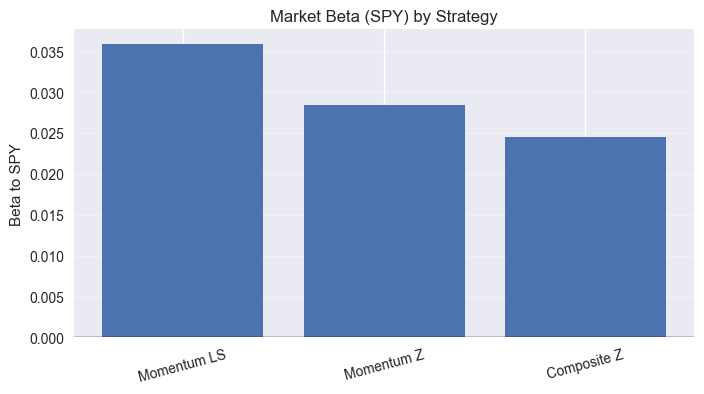

In [24]:
plt.figure(figsize=(8, 4))
plt.bar(regression_df["Strategy"], regression_df["beta_SPY"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Market Beta (SPY) by Strategy")
plt.ylabel("Beta to SPY")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.show()


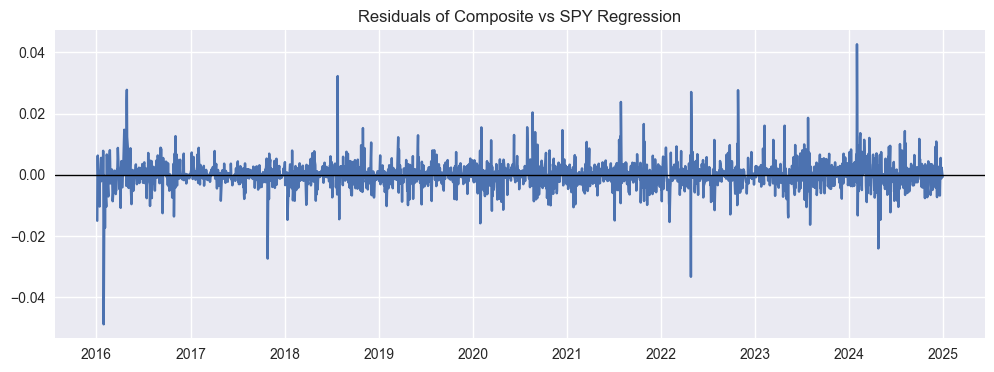

In [25]:
residuals = results_comp.resid

plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.title("Residuals of Composite vs SPY Regression")
plt.axhline(0, color="black", linewidth=1)
plt.grid(True)
plt.show()